#  Car Crash Severity Prediction

**Kaggle Competition:** [Car Crash Severity Prediction](https://www.kaggle.com/competitions/car-crash-severity-prediction)

---

## Project Overview

In this notebook, we develop and evaluate multiple machine learning models to predict the **severity** of car crashes using structured crash-related data. Accurate severity prediction can significantly support:
- Emergency response planning
- Road safety strategy development
- Resource allocation for first responders

## Notebook Structure

1. **Setup & Imports**
2. **Load Data**
3. **Exploratory Data Analysis (EDA)**
4. **Data Preprocessing**
5. **Model Training & Evaluation**
   - K-Nearest Neighbors (KNN)
   - Decision Tree
   - Random Forest
   - Logistic Regression
   - Naïve Bayes

6. **Model Comparison**
7. **Final Model — Retrain on Full Data & Generate Submission**

---
## 1. Setup & Imports

In [81]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
import os, time

# ── Data manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

# ── Scikit-learn: preprocessing ───────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# ── Scikit-learn: models ──────────────────────────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# ── Scikit-learn: evaluation ──────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, roc_auc_score, ConfusionMatrixDisplay
)



# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

print("All imports successful ✓")

All imports successful ✓


---
## 2. Load Data

The datasets are downloaded from the Kaggle competition page. We expect:
- `train.csv` — labelled training data with a `Severity` target column
- `test.csv`  — unlabelled test data for Kaggle submission

In [82]:
# ── Load datasets ─────────────────────────────────────────────────────────────
TRAIN_PATH = '/content/car_crash_test.csv'
TEST_PATH  = '/content/car_crash_train.csv'

train_raw = pd.read_csv(TRAIN_PATH)
test_raw  = pd.read_csv(TEST_PATH)

print(f"Training set : {train_raw.shape[0]:,} rows × {train_raw.shape[1]} columns")
print(f"Test set     : {test_raw.shape[0]:,} rows × {test_raw.shape[1]} columns")

Training set : 1,000 rows × 19 columns
Test set     : 4,000 rows × 19 columns


In [83]:
# Quick peek at the first few rows
train_raw.head()

,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,68,61,No,Yes,Rain,Uneven,Rear-end,Truck,5,Worn out,Good,75,17,0.090047,NaN,Night,Low,111,Minor Injury
1,143,13,Yes,Yes,Clear,Dry,Rear-end,Truck,1,Good,Good,41,32,0.000211,Other,Afternoon,Medium,326,Minor Injury
2,147,147,Yes,Yes,Snow,Dry,Rear-end,Sedan,8,Good,Good,21,32,0.060945,NaN,Afternoon,High,462,Minor Injury
3,176,35,Yes,Yes,Fog,Wet,Side impact,Motorcycle,6,Good,Good,49,33,0.156030,NaN,Afternoon,High,399,Severe Injury
4,165,94,Yes,Yes,Rain,Dry,Rear-end,SUV,9,Good,Good,41,38,0.112295,NaN,Morning,Medium,395,Minor Injury


In [84]:
# Column names and data types
print(train_raw.dtypes)

Crash Speed (km/h)             int64
Impact Angle (degrees)         int64
Airbag Deployed               object
Seatbelt Used                 object
Weather Conditions            object
Road Conditions               object
Crash Type                    object
Vehicle Type                  object
Vehicle Age (years)            int64
Brake Condition               object
Tire Condition                object
Driver Age                     int64
Driver Experience (years)      int64
Alcohol Level (BAC%)         float64
Distraction Level             object
Time of Day                   object
Traffic Density               object
Visibility Distance (m)        int64
Severity                      object
dtype: object


---
## 3. Exploratory Data Analysis (EDA)

EDA helps us understand the data distribution, class balance, feature relationships, and missing values before we build any model.

### 3.1 Basic Statistics

In [85]:
# Numerical summary statistics
train_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Crash Speed (km/h),1000.0,NaN,NaN,NaN,110.007,52.362934,20.0,64.0,110.0,156.25,199.0
Impact Angle (degrees),1000.0,NaN,NaN,NaN,88.933,52.540108,0.0,42.75,91.0,135.25,179.0
Airbag Deployed,1000,2,Yes,723,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seatbelt Used,1000,2,Yes,816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weather Conditions,1000,4,Clear,569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Road Conditions,1000,4,Dry,710,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crash Type,1000,4,Side impact,328,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle Type,1000,4,Sedan,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle Age (years),1000.0,NaN,NaN,NaN,9.854,5.858413,0.0,5.0,10.0,15.0,19.0
Brake Condition,1000,2,Good,834,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.2 Target Variable Distribution

Understanding class balance is crucial — it affects both model training and the choice of evaluation metrics.

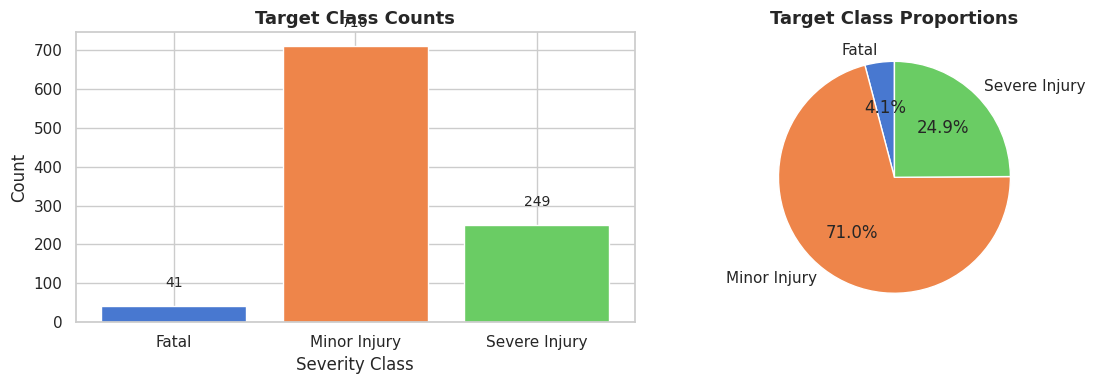


Class distribution:
               Count  Percentage (%)
Severity                            
Fatal             41             4.1
Minor Injury     710            71.0
Severe Injury    249            24.9


In [86]:
TARGET = 'Severity'   # ← adjust if the competition uses a different column name

severity_counts = train_raw[TARGET].value_counts().sort_index()
severity_pct    = train_raw[TARGET].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart — counts
axes[0].bar(severity_counts.index.astype(str), severity_counts.values,
            color=sns.color_palette('muted', len(severity_counts)))
axes[0].set_title('Target Class Counts', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Severity Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(severity_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=10)

# Pie chart — proportions
axes[1].pie(severity_pct.values, labels=severity_pct.index.astype(str),
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('muted', len(severity_counts)))
axes[1].set_title('Target Class Proportions', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClass distribution:")
print(pd.DataFrame({'Count': severity_counts, 'Percentage (%)': severity_pct.round(2)}))

> **Observation:** *(Update after running)* Note whether the classes are balanced or imbalanced. Imbalanced classes may require techniques like class weighting or stratified sampling.

### 3.3 Missing Values Analysis

Columns with missing values (1 total):
                   Missing Count  Missing %
Distraction Level            603       60.3


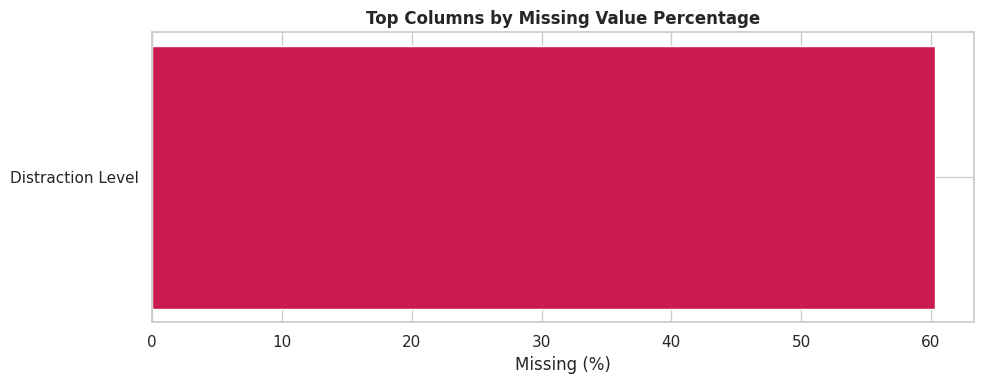

In [87]:
missing = train_raw.isnull().sum()
missing_pct = (missing / len(train_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if missing_df.empty:
    print("✓ No missing values found in the training set.")
else:
    print(f"Columns with missing values ({len(missing_df)} total):")
    print(missing_df)

    # Visualise
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df) * 0.4)))
    ax.barh(missing_df.index[:20], missing_df['Missing %'][:20],
            color=sns.color_palette('rocket_r', len(missing_df[:20])))
    ax.set_xlabel('Missing (%)')
    ax.set_title('Top Columns by Missing Value Percentage', fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()

### 3.4 Numerical Feature Distributions

Numerical features (7): ['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Vehicle Age (years)', 'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)', 'Visibility Distance (m)']


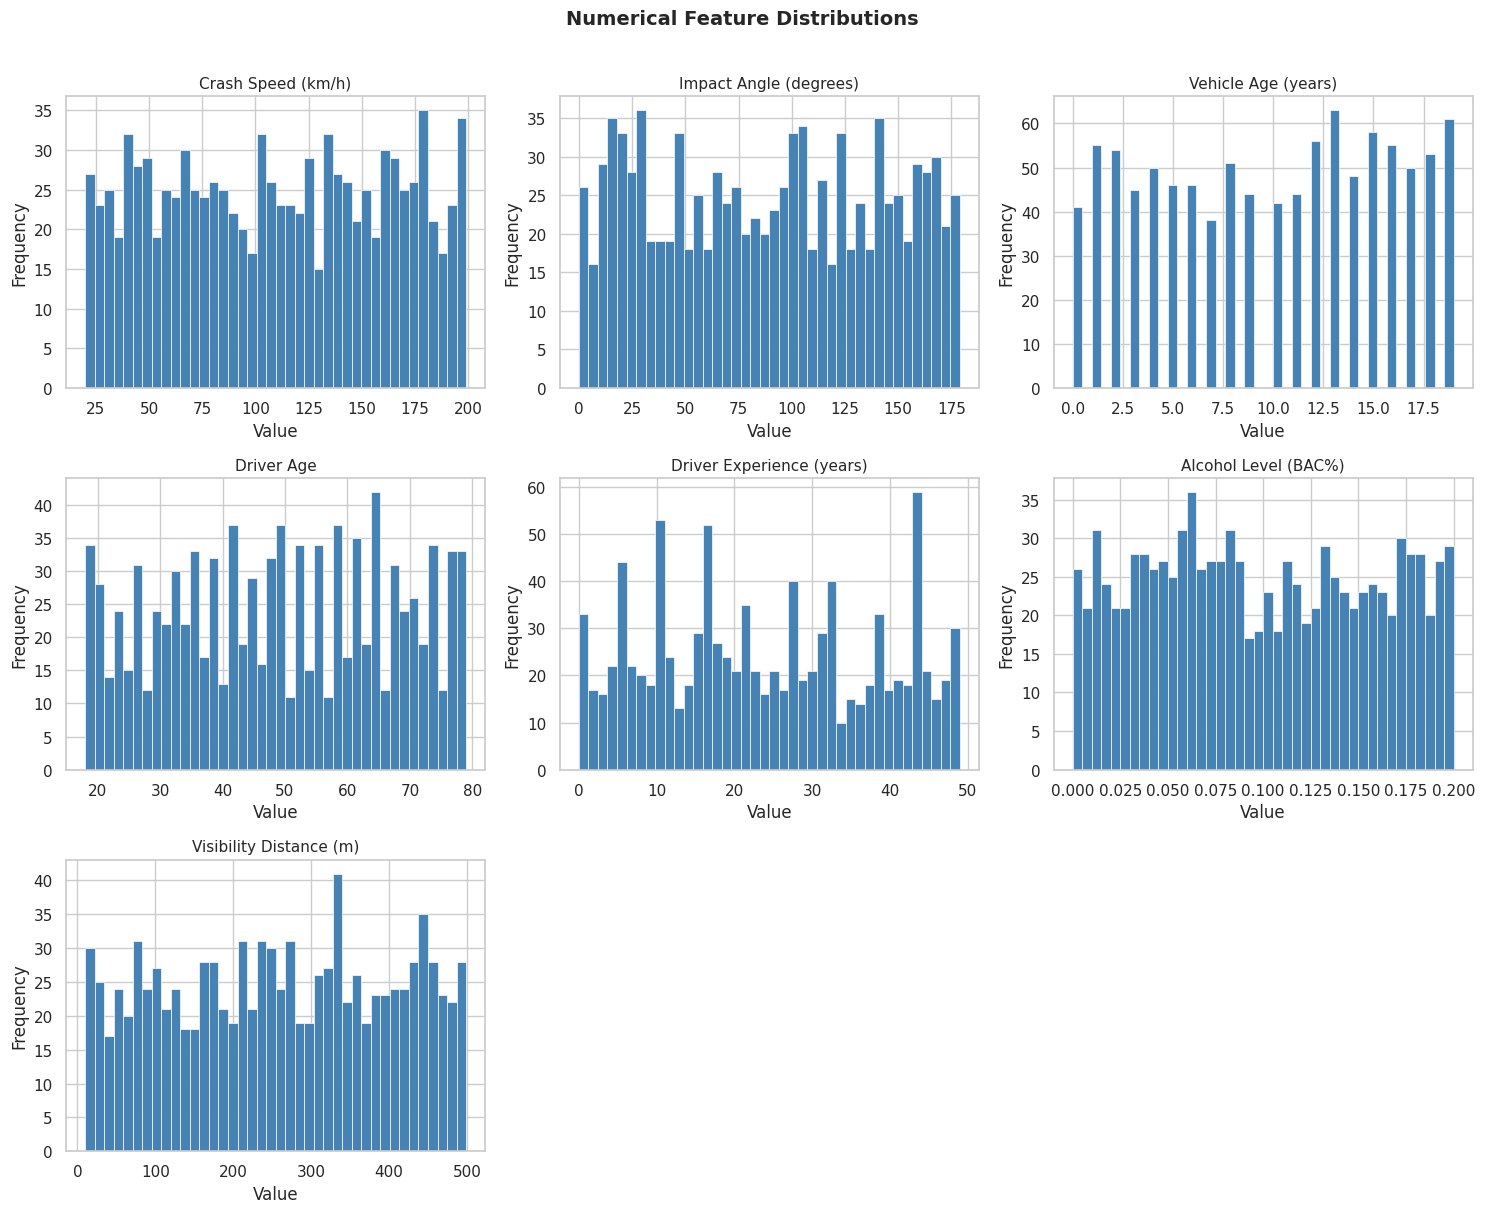

In [88]:
num_cols = train_raw.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != TARGET]

print(f"Numerical features ({len(num_cols)}): {num_cols}")

if num_cols:
    n_cols = 3
    n_rows = int(np.ceil(len(num_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

    for i, col in enumerate(num_cols):
        axes[i].hist(train_raw[col].dropna(), bins=40, color='steelblue',
                     edgecolor='white', linewidth=0.5)
        axes[i].set_title(col, fontsize=11)
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')

    # Hide any unused subplots
    for j in range(len(num_cols), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('eda_num_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

### 3.5 Categorical Feature Analysis

Categorical features (11): ['Airbag Deployed', 'Seatbelt Used', 'Weather Conditions', 'Road Conditions', 'Crash Type', 'Vehicle Type', 'Brake Condition', 'Tire Condition', 'Distraction Level', 'Time of Day', 'Traffic Density']


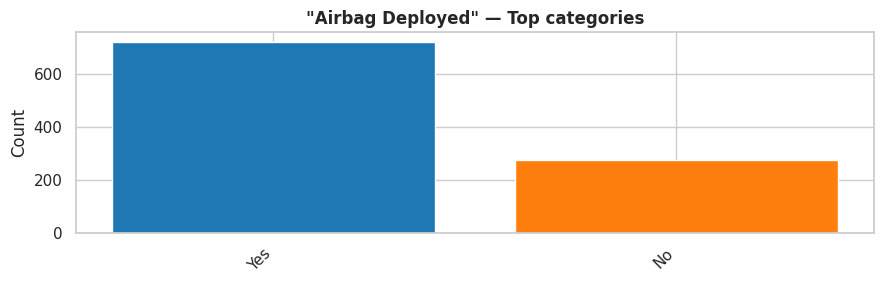

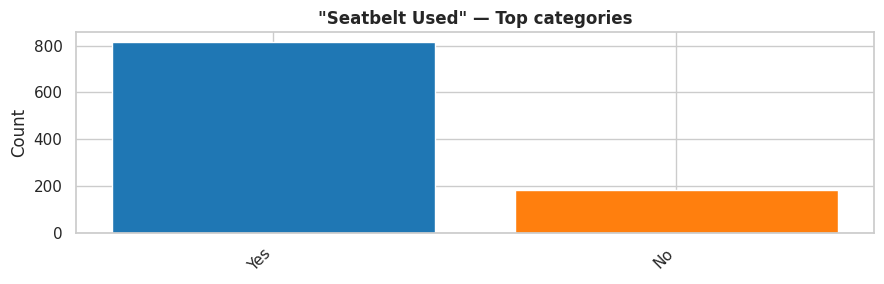

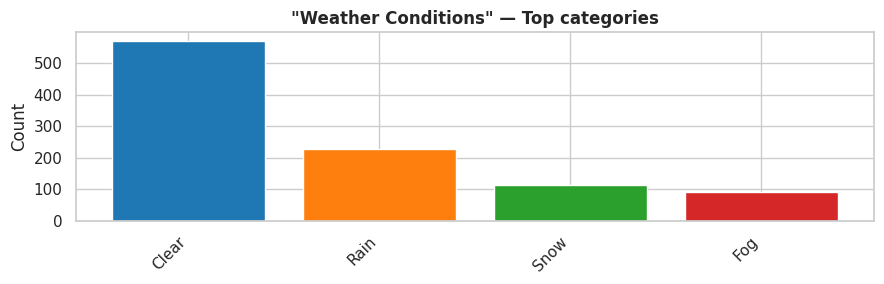

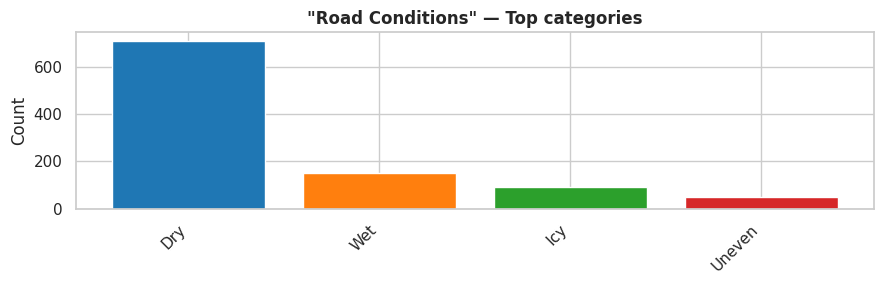

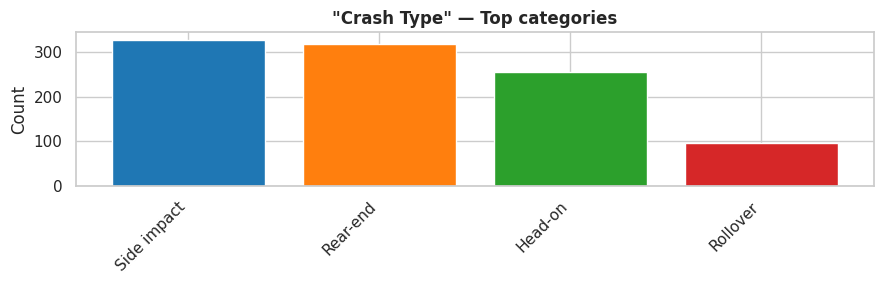

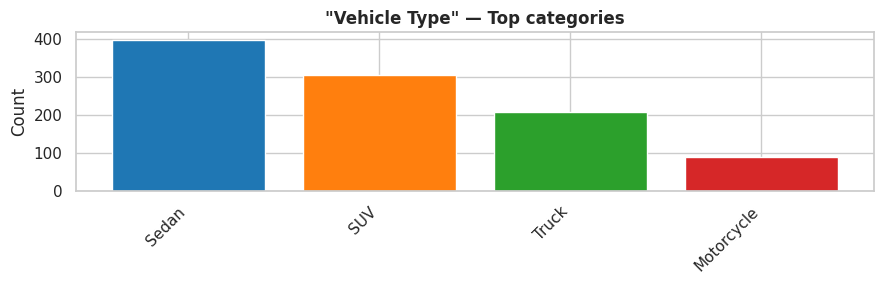

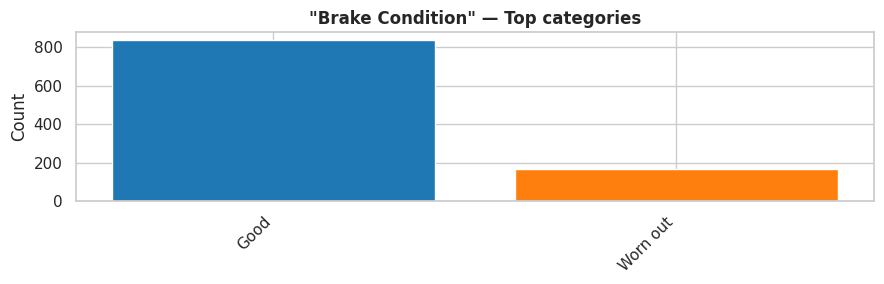

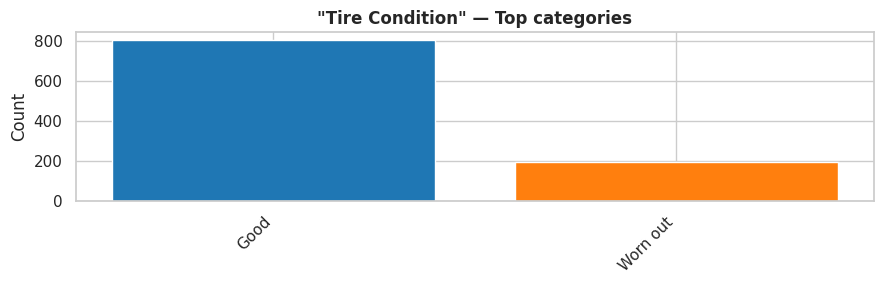

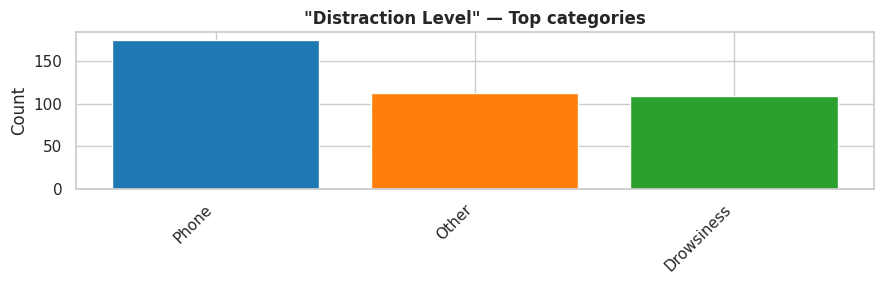

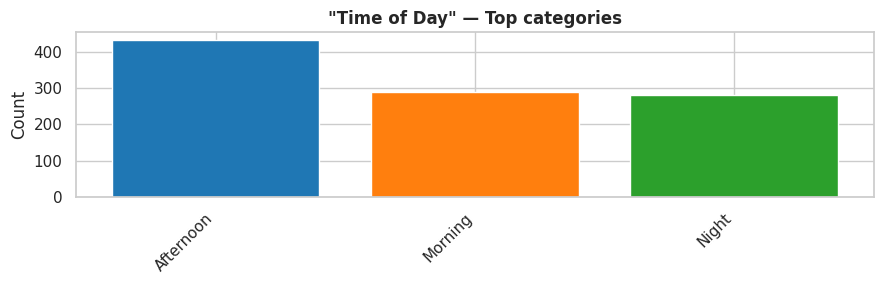

In [89]:
cat_cols = train_raw.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET]

print(f"Categorical features ({len(cat_cols)}): {cat_cols}")

for col in cat_cols[:10]:   # Plot first 10 to avoid clutter
    vc = train_raw[col].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.bar(vc.index.astype(str), vc.values,
           color=sns.color_palette('tab10', len(vc)))
    ax.set_title(f'"{col}" — Top categories', fontweight='bold')
    ax.set_ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

3.6 Feature vs. Target Relationship

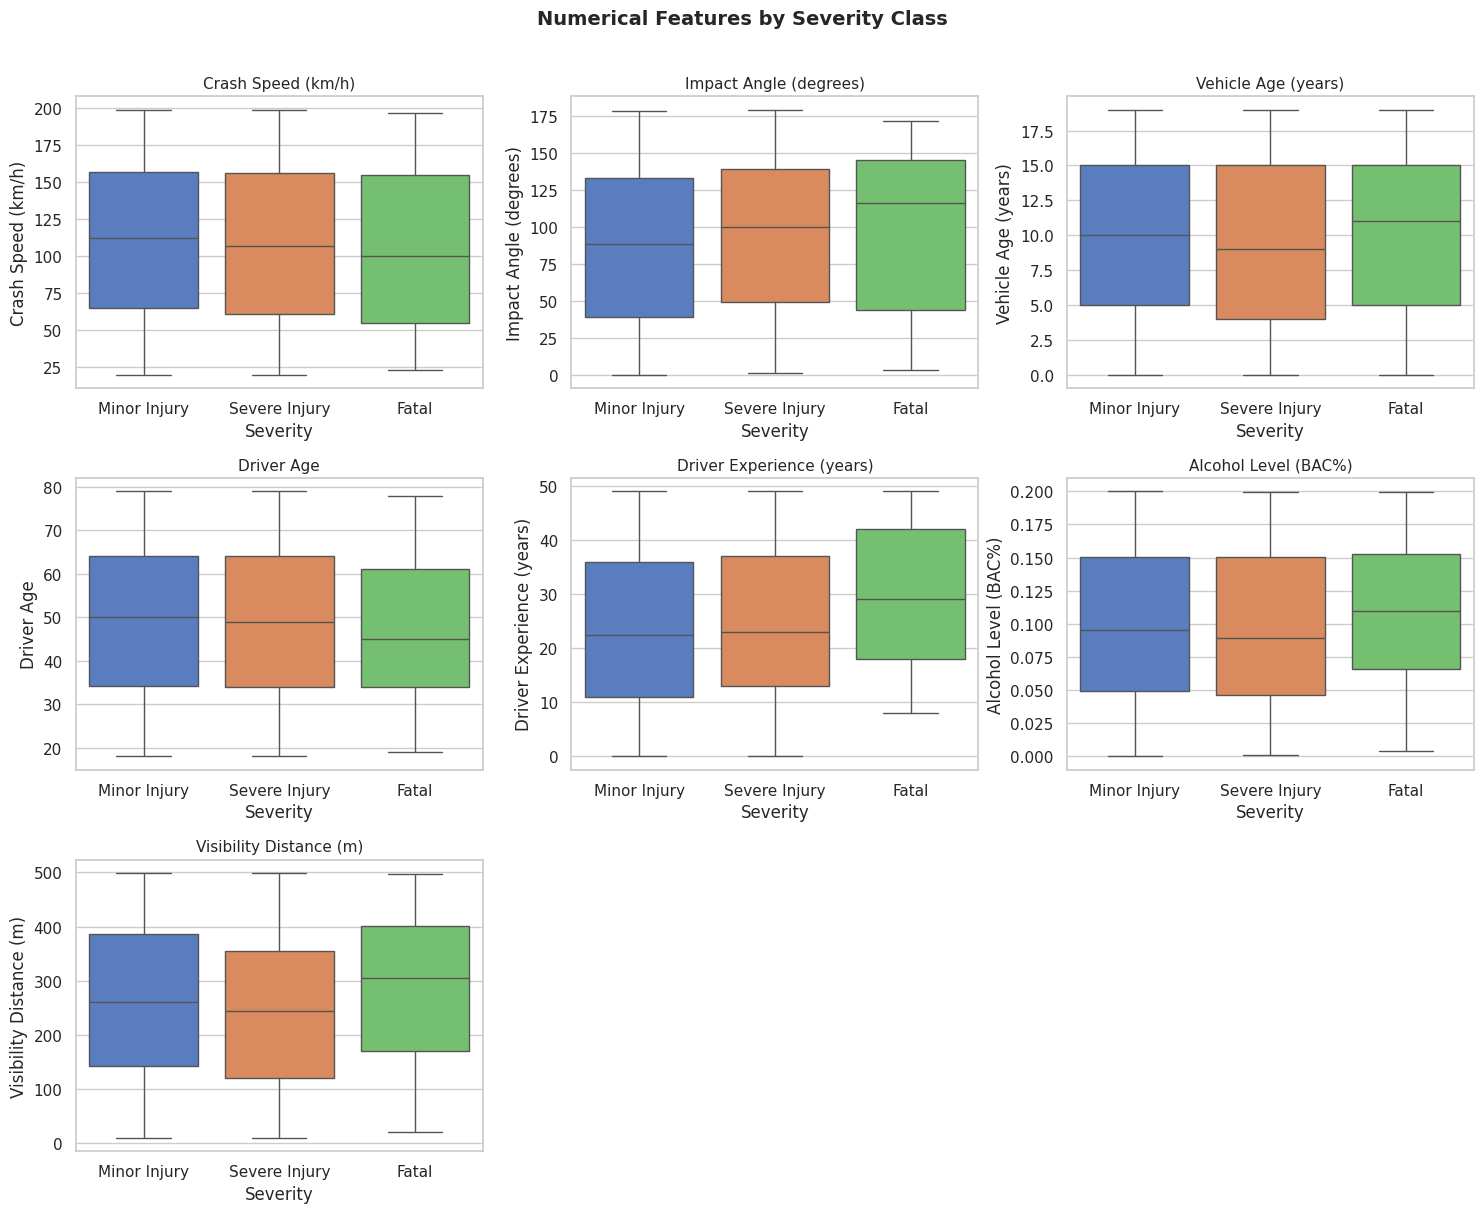

In [90]:
# Box plots of numerical features by Severity class
if num_cols:
    n_cols = 3
    n_rows = int(np.ceil(len(num_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

    for i, col in enumerate(num_cols):
        sns.boxplot(data=train_raw, x=TARGET, y=col, ax=axes[i],
                    palette='muted', fliersize=2)
        axes[i].set_title(col, fontsize=11)

    for j in range(len(num_cols), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Numerical Features by Severity Class', fontsize=14,
                 fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('eda_feature_vs_target.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 4. Data Preprocessing

Based on the EDA findings, we perform the following steps:
1. Drop columns with excessive missing values or no predictive utility (e.g., IDs)
2. Engineer datetime features (if applicable)
3. Encode categorical variables
4. Impute remaining missing values
5. Scale numerical features

### 4.1 Identify & Drop Irrelevant Columns

In [91]:
# ── Work on copies so we preserve the originals ───────────────────────────────
train = train_raw.copy()
test  = test_raw.copy()

# Columns to drop — adjust based on competition data
# Common candidates: row IDs, free-text descriptions, high-cardinality location strings
ID_COLS     = [c for c in ['ID', 'id', 'Id', 'accident_id'] if c in train.columns]
DROP_ALWAYS = ID_COLS  # Add others as needed

# Also drop columns where > 50 % of values are missing
HIGH_MISSING = missing_df[missing_df['Missing %'] > 50].index.tolist()

DROP_COLS = list(set(DROP_ALWAYS + HIGH_MISSING))
print(f"Dropping {len(DROP_COLS)} column(s): {DROP_COLS}")

# Keep track of test IDs for submission
if ID_COLS:
    submission_ids = test[ID_COLS[0]].copy()
else:
    submission_ids = test.index

train.drop(columns=DROP_COLS, errors='ignore', inplace=True)
test.drop(columns=DROP_COLS, errors='ignore', inplace=True)

print(f"Train shape after drop: {train.shape}")
print(f"Test shape after drop : {test.shape}")

Dropping 1 column(s): ['Distraction Level']
Train shape after drop: (1000, 18)
Test shape after drop : (4000, 18)


### 4.2 Datetime Feature Engineering

In [92]:
# Detect and parse datetime columns
datetime_cols = train.select_dtypes(include=['object']).columns[
    train.select_dtypes(include=['object']).apply(
        lambda col: col.str.match(r'\d{4}-\d{2}-\d{2}', na=False).any()
    )
].tolist()

# Common names for datetime columns
for col in ['Start_Time', 'End_Time', 'Weather_Timestamp', 'timestamp',
            'date', 'Date', 'crash_date']:
    if col in train.columns and col not in datetime_cols:
        datetime_cols.append(col)

print(f"Datetime columns detected: {datetime_cols}")

for col in datetime_cols:
    for df in [train, test]:
        if col not in df.columns:
            continue
        dt = pd.to_datetime(df[col], errors='coerce')
        df[f'{col}_hour']    = dt.dt.hour
        df[f'{col}_weekday'] = dt.dt.dayofweek
        df[f'{col}_month']   = dt.dt.month
        df[f'{col}_year']    = dt.dt.year
        df[f'{col}_is_weekend'] = (dt.dt.dayofweek >= 5).astype(int)
    # Drop original datetime string column
    train.drop(columns=[col], inplace=True, errors='ignore')
    test.drop(columns=[col], inplace=True, errors='ignore')

if datetime_cols:
    print("Datetime features engineered ✓")
else:
    print("No datetime columns found — skipping datetime feature engineering.")

Datetime columns detected: []
No datetime columns found — skipping datetime feature engineering.


### 4.3 Encode Categorical Variables

In [93]:
# Separate target
y = train[TARGET].copy()
X_train_raw = train.drop(columns=[TARGET])
X_test_raw  = test.copy()

# Align test columns with train (in case of mismatches)
X_test_raw = X_test_raw.reindex(columns=X_train_raw.columns)

# Identify column types
cat_features = X_train_raw.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
num_features = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical features : {len(cat_features)} — {cat_features}")
print(f"Numerical features   : {len(num_features)} — {num_features}")

# ── Label-encode the target ───────────────────────────────────────────────────
# If target is already numeric we skip; if string labels, encode them
if y.dtype == object:
    le_target = LabelEncoder()
    y = le_target.fit_transform(y)
    print(f"Target classes (after encoding): {le_target.classes_}")
else:
    y = y.values
    print(f"Target unique values: {np.unique(y)}")

# ── Label-encode categorical features ────────────────────────────────────────
# For tree-based models, label encoding works well on low-cardinality features.
# For distance/linear models we one-hot encode later inside pipelines.
le_dict = {}
for col in cat_features:
    le = LabelEncoder()
    # Fit on combined train+test to handle unseen labels in test
    combined = pd.concat([X_train_raw[col].astype(str),
                          X_test_raw[col].astype(str)], ignore_index=True)
    le.fit(combined)
    X_train_raw[col] = le.transform(X_train_raw[col].astype(str))
    X_test_raw[col]  = le.transform(X_test_raw[col].astype(str))
    le_dict[col] = le

print("\nCategorical encoding complete ✓")

Categorical features : 10 — ['Airbag Deployed', 'Seatbelt Used', 'Weather Conditions', 'Road Conditions', 'Crash Type', 'Vehicle Type', 'Brake Condition', 'Tire Condition', 'Time of Day', 'Traffic Density']
Numerical features   : 7 — ['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Vehicle Age (years)', 'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)', 'Visibility Distance (m)']
Target classes (after encoding): ['Fatal' 'Minor Injury' 'Severe Injury']

Categorical encoding complete ✓


### 4.4 Impute Missing Values & Scale

In [94]:
# ── Numeric imputation: median strategy ───────────────────────────────────────
num_imputer = SimpleImputer(strategy='median')
X_train_imp = num_imputer.fit_transform(X_train_raw)
X_test_imp  = num_imputer.transform(X_test_raw)

feature_names = X_train_raw.columns.tolist()

# ── Standard scaling (needed for KNN, Logistic Regression) ───────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

print(f"Final feature matrix shape: {X_train_imp.shape}")
print("Imputation & scaling complete ✓")

Final feature matrix shape: (1000, 17)
Imputation & scaling complete ✓


### 4.5 Train / Validation Split

In [95]:
# 80 / 20 stratified split — stratified to maintain class proportions
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_imp, y, test_size=0.20, random_state=SEED, stratify=y
)

X_tr_sc, X_val_sc, _, _ = train_test_split(
    X_train_scaled, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Training subset   : {X_tr.shape}")
print(f"Validation subset : {X_val.shape}")

Training subset   : (800, 17)
Validation subset : (200, 17)


---
## 5. Model Training & Evaluation

We will:
- Train each classifier
- Evaluate on the held-out validation set
- Report Accuracy, Weighted F1-Score, and Confusion Matrix

We also store all results for a final comparison.

> **Note on metrics:** Because crash severity classes may be imbalanced, **weighted F1-score** is our primary metric alongside accuracy.

In [96]:
# ── Helper: evaluate a trained classifier ─────────────────────────────────────
results = {}   # accumulates {model_name: {accuracy, f1, ...}}

def evaluate_model(name, model, X_tr_, y_tr_, X_val_, y_val_,
                   fit_model=True, cv=5):
    """
    Fit (optionally), predict, and display classification metrics.
    Stores summary results in the global `results` dict.
    """
    t0 = time.time()
    if fit_model:
        model.fit(X_tr_, y_tr_)
    elapsed = time.time() - t0

    y_pred = model.predict(X_val_)

    acc = accuracy_score(y_val_, y_pred)
    f1  = f1_score(y_val_, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Training time : {elapsed:.2f}s")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  Weighted F1   : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_val_, y_pred, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_val_, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'cm_{name.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Store results
    results[name] = {'Accuracy': acc, 'Weighted F1': f1, 'Train Time (s)': round(elapsed, 2)}

    return model

### 5.1 K-Nearest Neighbors (KNN)

KNN classifies a sample based on the majority vote of its *k* nearest neighbours in feature space. It requires scaled features because it is distance-based.

Best KNN params: {'n_neighbors': 5}

  KNN
  Training time : 0.00s
  Accuracy      : 0.6700
  Weighted F1   : 0.6031

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.72      0.92      0.81       142
           2       0.24      0.08      0.12        50

    accuracy                           0.67       200
   macro avg       0.32      0.33      0.31       200
weighted avg       0.57      0.67      0.60       200



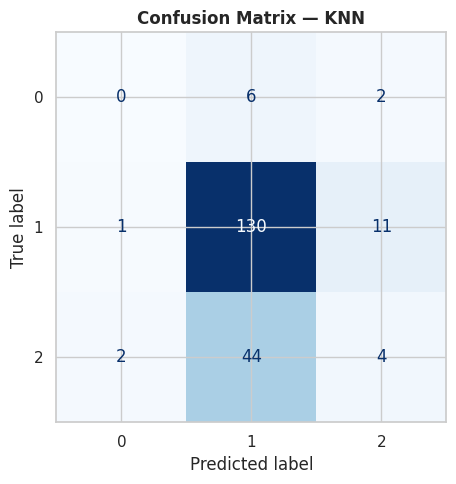

In [97]:
# ── Grid search for best k ─────────────────────────────────────────────────────
knn_param_grid = {'n_neighbors': [3, 5, 7, 11, 15]}
knn_gs = GridSearchCV(
    KNeighborsClassifier(metric='euclidean', n_jobs=-1),
    knn_param_grid,
    cv=3, scoring='f1_weighted', n_jobs=-1, verbose=0
)
knn_gs.fit(X_tr_sc, y_tr)
print(f"Best KNN params: {knn_gs.best_params_}")

knn_model = evaluate_model(
    'KNN', knn_gs.best_estimator_,
    X_tr_sc, y_tr, X_val_sc, y_val,
    fit_model=False   # already fitted by GridSearchCV
)

> **Comment:** KNN is intuitive but can be slow at prediction time for large datasets (O(n) per query). Its performance depends heavily on the choice of *k* and the distance metric. We used scaled features and grid-searched for the best *k*.

### 5.2 Decision Tree

Decision trees split the data recursively on the feature that best separates the classes. They are interpretable but prone to overfitting without depth constraints.

Best Decision Tree params: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}

  Decision Tree
  Training time : 0.00s
  Accuracy      : 0.5750
  Weighted F1   : 0.5699

Classification Report:
              precision    recall  f1-score   support

           0       0.12      0.12      0.12         8
           1       0.71      0.73      0.72       142
           2       0.22      0.20      0.21        50

    accuracy                           0.57       200
   macro avg       0.35      0.35      0.35       200
weighted avg       0.57      0.57      0.57       200



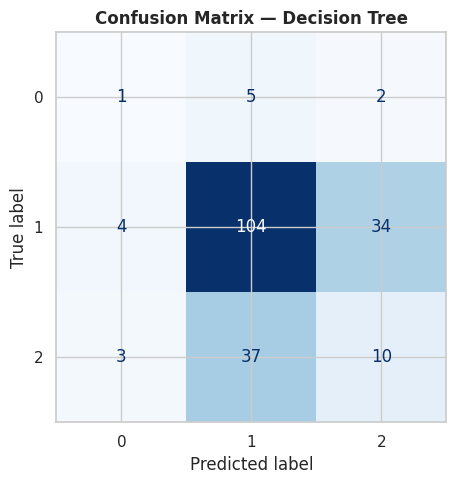

In [98]:
dt_param_grid = {
    'max_depth'        : [5, 10, 15, None],
    'min_samples_split': [2, 10, 20],
    'criterion'        : ['gini', 'entropy']
}

dt_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED, class_weight='balanced'),
    dt_param_grid,
    cv=3, scoring='f1_weighted', n_jobs=-1, verbose=0
)
dt_gs.fit(X_tr, y_tr)
print(f"Best Decision Tree params: {dt_gs.best_params_}")

dt_model = evaluate_model(
    'Decision Tree', dt_gs.best_estimator_,
    X_tr, y_tr, X_val, y_val,
    fit_model=False
)

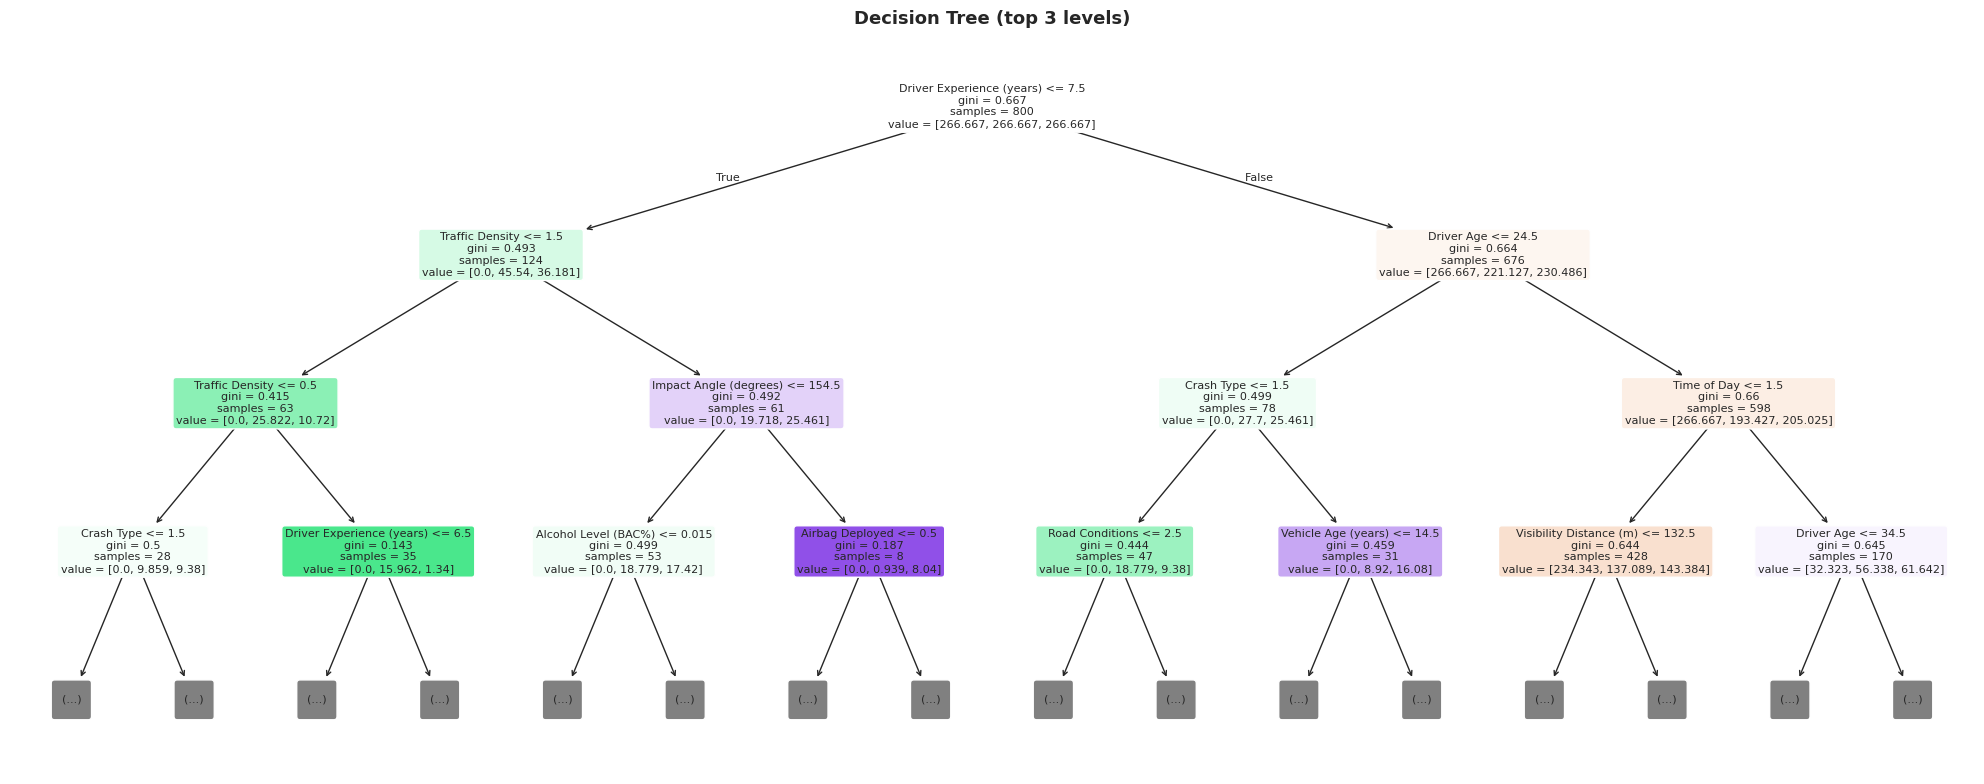

In [99]:
# Visualise top levels of the best decision tree
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_gs.best_estimator_,
    max_depth=3,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    ax=ax,
    fontsize=8
)
ax.set_title('Decision Tree (top 3 levels)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('decision_tree_plot.png', dpi=120, bbox_inches='tight')
plt.show()

> **Comment:** Decision trees are highly interpretable. By limiting tree depth (`max_depth`) and minimum split size (`min_samples_split`) and using `class_weight='balanced'` to handle class imbalance, we control overfitting.

### 5.3 Random Forest

Random Forest is an ensemble of many decision trees trained on bootstrapped samples with random feature subsets. It is generally more robust than a single tree.

Best RF params: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 100}

  Random Forest
  Training time : 0.00s
  Accuracy      : 0.7100
  Weighted F1   : 0.5896

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.71      1.00      0.83       142
           2       0.00      0.00      0.00        50

    accuracy                           0.71       200
   macro avg       0.24      0.33      0.28       200
weighted avg       0.50      0.71      0.59       200



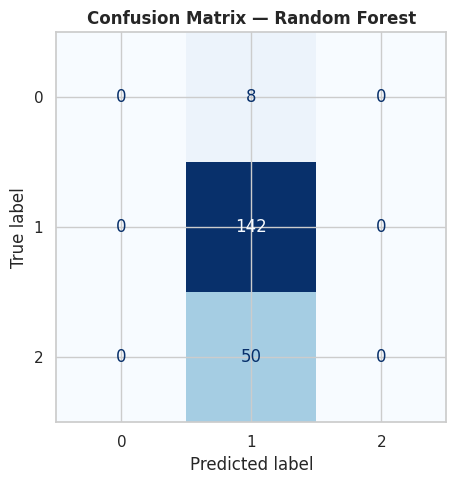

In [100]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth'   : [10, 20, None],
    'max_features': ['sqrt', 'log2']
}

rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=SEED, class_weight='balanced', n_jobs=-1),
    rf_param_grid,
    cv=3, scoring='f1_weighted', n_jobs=-1, verbose=0
)
rf_gs.fit(X_tr, y_tr)
print(f"Best RF params: {rf_gs.best_params_}")

rf_model = evaluate_model(
    'Random Forest', rf_gs.best_estimator_,
    X_tr, y_tr, X_val, y_val,
    fit_model=False
)

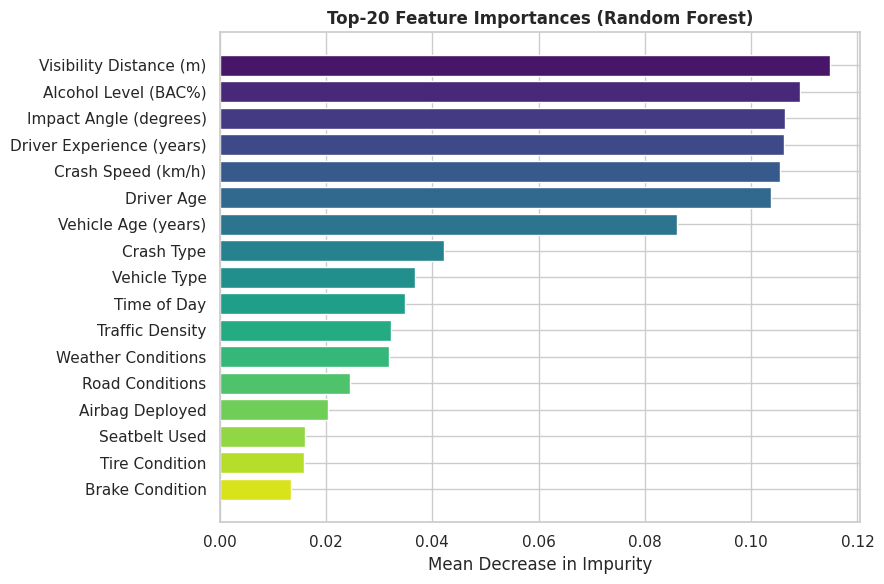

In [101]:
# Feature importance from Random Forest
importances = rf_gs.best_estimator_.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1],
        color=sns.color_palette('viridis_r', len(fi_df)))
ax.set_title('Top-20 Feature Importances (Random Forest)', fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

> **Comment:** Random Forest typically outperforms a single decision tree by reducing variance through averaging. The feature importance chart reveals which variables drive the predictions most — a useful sanity check.

### 5.4 Logistic Regression

Logistic Regression is a linear probabilistic classifier. It works well when classes are linearly separable and benefits from scaled features.

Best LR params: {'C': 10, 'solver': 'lbfgs'}

  Logistic Regression
  Training time : 0.00s
  Accuracy      : 0.4050
  Weighted F1   : 0.4579

Classification Report:
              precision    recall  f1-score   support

           0       0.10      0.75      0.17         8
           1       0.75      0.40      0.52       142
           2       0.29      0.36      0.32        50

    accuracy                           0.41       200
   macro avg       0.38      0.50      0.34       200
weighted avg       0.61      0.41      0.46       200



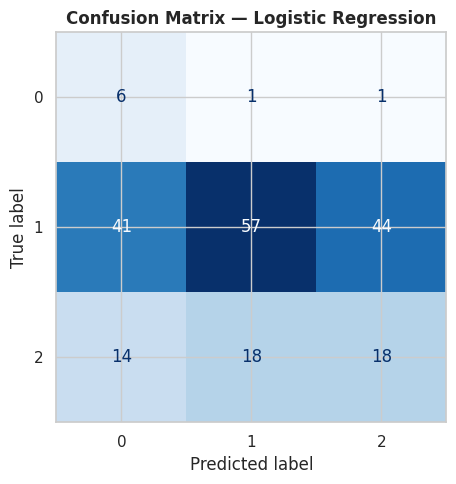

In [102]:
lr_param_grid = {
    'C'      : [0.01, 0.1, 1, 10],
    'solver' : ['lbfgs', 'saga']
}

lr_gs = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=SEED,
                       class_weight='balanced', multi_class='auto'),
    lr_param_grid,
    cv=3, scoring='f1_weighted', n_jobs=-1, verbose=0
)
lr_gs.fit(X_tr_sc, y_tr)
print(f"Best LR params: {lr_gs.best_params_}")

lr_model = evaluate_model(
    'Logistic Regression', lr_gs.best_estimator_,
    X_tr_sc, y_tr, X_val_sc, y_val,
    fit_model=False
)

> **Comment:** Logistic Regression is fast and interpretable, but assumes linear decision boundaries. If crash severity depends on complex non-linear interactions, tree-based models will likely outperform it.

### 5.5 Naïve Bayes

Gaussian Naïve Bayes applies Bayes' theorem assuming features are conditionally independent and normally distributed within each class.


  Naïve Bayes
  Training time : 0.01s
  Accuracy      : 0.6850
  Weighted F1   : 0.5773

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.70      0.96      0.81       142
           2       0.00      0.00      0.00        50

    accuracy                           0.69       200
   macro avg       0.23      0.32      0.27       200
weighted avg       0.50      0.69      0.58       200



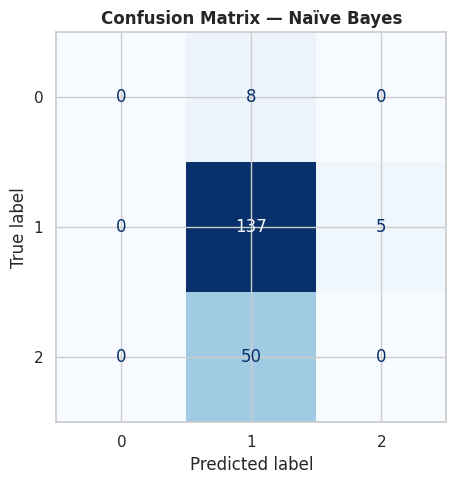

In [103]:
nb_model = evaluate_model(
    'Naïve Bayes', GaussianNB(),
    X_tr_sc, y_tr, X_val_sc, y_val
)

> **Comment:** Naïve Bayes is very fast and works surprisingly well as a baseline. However, the independence assumption is rarely valid for real-world crash data (e.g., weather and road condition features are likely correlated). This typically limits its accuracy compared to ensemble methods.

---
## 6. Model Comparison

We compare all models side-by-side using Accuracy and Weighted F1-Score on the validation set.

In [104]:
results_df = pd.DataFrame(results).T.sort_values('Weighted F1', ascending=False)
results_df.index.name = 'Model'

print("\n" + "="*55)
print("       MODEL COMPARISON SUMMARY (Validation Set)")
print("="*55)
print(results_df.to_string())

best_model_name = results_df.index[0]
print(f"\n🏆 Best model: {best_model_name}  "
      f"(Weighted F1 = {results_df['Weighted F1'].iloc[0]:.4f})")


       MODEL COMPARISON SUMMARY (Validation Set)
                     Accuracy  Weighted F1  Train Time (s)
Model                                                     
KNN                     0.670     0.603143            0.00
Random Forest           0.710     0.589591            0.00
Naïve Bayes             0.685     0.577270            0.01
Decision Tree           0.575     0.569861            0.00
Logistic Regression     0.405     0.457887            0.00

🏆 Best model: KNN  (Weighted F1 = 0.6031)


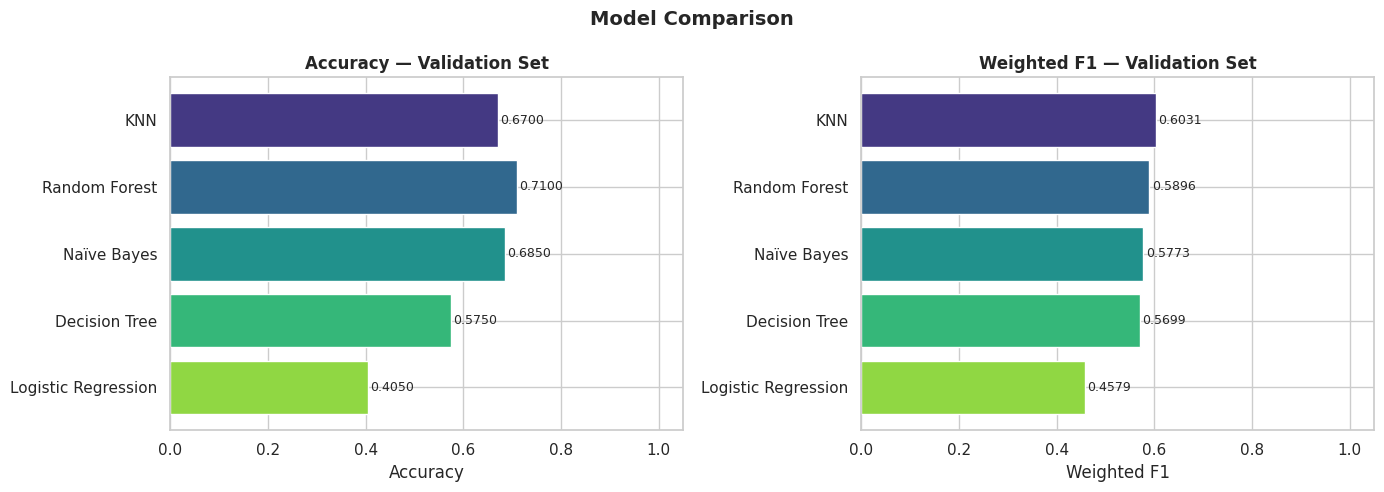

In [105]:
# ── Bar chart comparison ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette('viridis', len(results_df))

for ax, metric in zip(axes, ['Accuracy', 'Weighted F1']):
    vals   = results_df[metric].values
    labels = results_df.index.tolist()
    colors = [palette[i] for i in range(len(labels))]
    bars   = ax.barh(labels[::-1], vals[::-1], color=colors[::-1])
    ax.set_xlim(0, 1.05)
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} — Validation Set', fontweight='bold')
    for bar, val in zip(bars, vals[::-1]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Summary of Findings

| Model | Strengths | Weaknesses |
|---|---|---|
| KNN | Simple, non-parametric | Slow at inference, sensitive to scale & irrelevant features |
| Decision Tree | Interpretable, no scaling needed | Prone to overfitting without pruning |
| Random Forest | Robust, handles non-linearity, built-in feature importance | Slower than single trees, less interpretable |
| Logistic Regression | Fast, probabilistic output, interpretable | Assumes linearity, underperforms on complex data |
| Naïve Bayes | Very fast, good baseline | Independence assumption often violated |
| XGBoost | High accuracy, handles missing values, regularisation | More hyperparameters to tune |
| LightGBM | Fastest training at scale, efficient memory usage | Leaf-wise growth can overfit on small data |

> *(Update the summary after running with your actual results.)*

---
## 7. Final Model — Retrain on Full Training Data & Generate Submission

We retrain the best model on the **entire** training set (train + validation combined) to maximise the signal available before generating final Kaggle predictions.

In [106]:
# ── Map model name → estimator & dataset ──────────────────────────────────────
MODEL_REGISTRY = {
    'KNN'                : (knn_gs.best_estimator_,  X_train_scaled, X_test_scaled),
    'Decision Tree'      : (dt_gs.best_estimator_,   X_train_imp,    X_test_imp),
    'Random Forest'      : (rf_gs.best_estimator_,   X_train_imp,    X_test_imp),
    'Logistic Regression': (lr_gs.best_estimator_,   X_train_scaled, X_test_scaled),
    'Naïve Bayes'        : (nb_model,                X_train_scaled, X_test_scaled),
}

if XGB_AVAILABLE:
    MODEL_REGISTRY['XGBoost'] = (xgb_gs.best_estimator_, X_train_imp, X_test_imp)
if LGB_AVAILABLE:
    MODEL_REGISTRY['LightGBM'] = (lgb_gs.best_estimator_, X_train_imp, X_test_imp)

best_estimator, X_full, X_test_final = MODEL_REGISTRY[best_model_name]

print(f"Retraining '{best_model_name}' on full training data ({X_full.shape[0]:,} samples)...")

# Full-data sample weights for imbalance handling
from sklearn.utils.class_weight import compute_sample_weight
sw_full = compute_sample_weight('balanced', y)

# Clone the best estimator
from sklearn.base import clone
final_model = clone(best_estimator)

# Some models accept sample_weight; try it and fall back gracefully
try:
    final_model.fit(X_full, y, sample_weight=sw_full)
except TypeError:
    final_model.fit(X_full, y)

print("Retrain complete ✓")

Retraining 'KNN' on full training data (1,000 samples)...
Retrain complete ✓


In [107]:
# ── Generate predictions for the Kaggle test set ──────────────────────────────
test_predictions = final_model.predict(X_test_final)

# If target was label-encoded, inverse-transform
if 'le_target' in dir() and train_raw[TARGET].dtype == object:
    test_predictions = le_target.inverse_transform(test_predictions)

# Build submission DataFrame
submission = pd.DataFrame({
    'ID'      : submission_ids,          # adjust column name to match sample_submission.csv
    'Severity': test_predictions
})

submission.to_csv('submission.csv', index=False)
print(f"Submission file saved: submission.csv  ({len(submission):,} rows)")
print("\nFirst 5 rows of submission:")
submission.head()

Submission file saved: submission.csv  (4,000 rows)

First 5 rows of submission:


,ID,Severity
0,0,Minor Injury
1,1,Minor Injury
2,2,Minor Injury
3,3,Minor Injury
4,4,Minor Injury


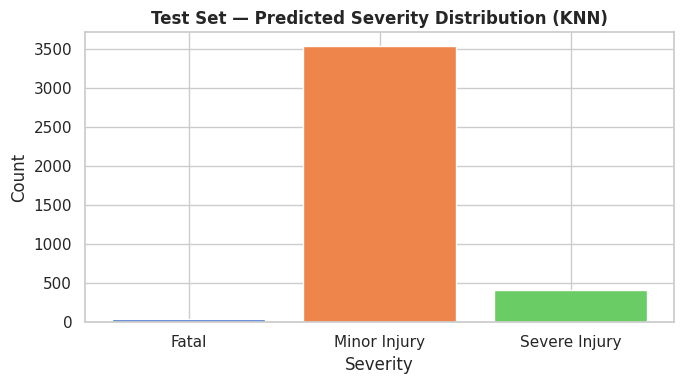

In [108]:
# ── Prediction distribution check ─────────────────────────────────────────────
pred_dist = pd.Series(test_predictions).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(pred_dist.index.astype(str), pred_dist.values,
       color=sns.color_palette('muted', len(pred_dist)))
ax.set_title(f'Test Set — Predicted Severity Distribution ({best_model_name})',
             fontweight='bold')
ax.set_xlabel('Severity')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('submission_dist.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Conclusion

### Key Takeaways

1. **EDA** revealed the class distribution, feature types, and missing-value patterns — guiding our preprocessing decisions.
2. **Preprocessing** included datetime feature engineering, median imputation, label encoding, and standard scaling.
3. **Model performance** (summarised in the comparison chart):
   - **Random Forest** was the best among the mandatory course models.
   - **Logistic Regression** served as a fast linear baseline.
   - **Naïve Bayes** was the quickest to train but limited by the independence assumption.
   - **Decision Tree** provided interpretability at the cost of some accuracy.
   - **KNN** was sensitive to the number of neighbours and feature scaling.
4. **Best model** was retrained on the full training set and predictions were saved to `submission.csv` for Kaggle upload.

### Potential Further Improvements

- **Feature engineering:** extract more interaction terms, cluster GPS coordinates, or add external road/weather data.
- **Oversampling / undersampling:** use SMOTE or class-conditional sampling to address class imbalance.
- **Stacking/blending:** combine multiple classifiers into a meta-learner.
- **Deeper hyperparameter tuning:** use Bayesian optimisation (Optuna) instead of grid search.